# 02 — Simulated Annealing

**Curso:** Inteligencia Artificial — Optimización

Este notebook contiene ejemplos guiados y actividades para desarrollar en clase.

## Objetivos

- comprender por qué aceptar temporalmente soluciones peores puede ser útil;
- implementar Simulated Annealing desde cero;
- interpretar el efecto de la temperatura y el calendario de enfriamiento;
- comparar Simulated Annealing con Hill Climbing.

![HillClimbing](https://drive.google.com/uc?export=view&id=13a1dTy2bf9BsgeSZH-cXqJndS1ZKU4DP)



## 1. Un paisaje con varios óptimos

Maximizaremos una función unidimensional multimodal:

$$
f(x)=\sin(3x)+0.35\sin(9x)-0.03(x-2)^2
$$

El algoritmo solo observará valores cercanos al estado actual.

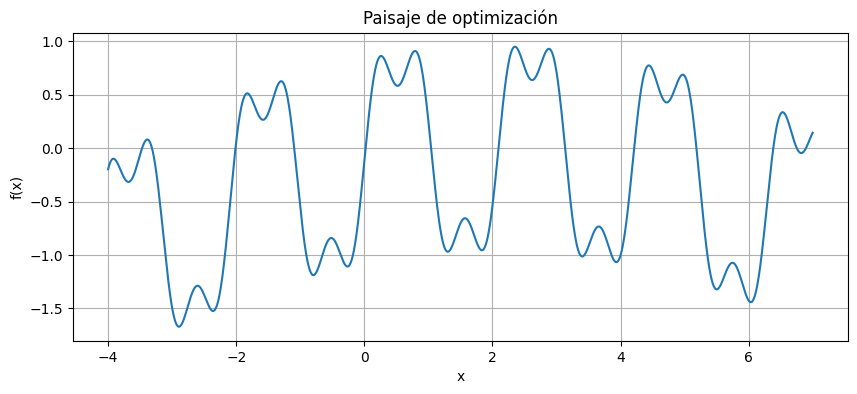

Mejor punto aproximado en la malla: x=2.355, f(x)=0.951


In [ ]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt

SEED = 21
random.seed(SEED)
np.random.seed(SEED)


def objective(x):
    return np.sin(3 * x) + 0.35 * np.sin(9 * x) - 0.03 * (x - 2) ** 2

LOWER, UPPER = -4.0, 7.0
xs = np.linspace(LOWER, UPPER, 1500)
ys = objective(xs)

plt.figure(figsize=(10, 4))
plt.plot(xs, ys)
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Paisaje de optimización')
plt.grid(True)
plt.show()

best_grid_x = xs[np.argmax(ys)]
print(f'Mejor punto aproximado en la malla: x={best_grid_x:.3f}, f(x)={objective(best_grid_x):.3f}')

## 2. Hill Climbing estocástico como línea base

Propondremos un vecino mediante una perturbación aleatoria pequeña. Hill Climbing acepta el candidato únicamente cuando mejora la función objetivo.

In [ ]:
def random_neighbor(x, step_size, rng, lower=LOWER, upper=UPPER):
    candidate = x + rng.uniform(-step_size, step_size)
    return min(upper, max(lower, candidate))


def stochastic_hill_climbing(x0, iterations=300, step_size=0.35, seed=0):
    rng = random.Random(seed)
    x = x0
    trajectory = [(x, float(objective(x)))]

    for _ in range(iterations):
        candidate = random_neighbor(x, step_size, rng)
        if objective(candidate) > objective(x):
            x = candidate
        trajectory.append((x, float(objective(x))))

    return x, trajectory

x0 = -2.5
hill_x, hill_trajectory = stochastic_hill_climbing(x0, seed=SEED)
print(f'Hill Climbing: x={hill_x:.3f}, f(x)={objective(hill_x):.3f}')

Hill Climbing: x=-2.603, f(x)=-1.288


## 3. Regla de aceptación

Sea

$$
\Delta = f(x')-f(x)
$$

Para maximización:

- si $\Delta>0$, aceptamos el candidato;
- si $\Delta\leq 0$, lo aceptamos con probabilidad

$$
P(\text{aceptar})=\exp\left(\frac{\Delta}{T}\right)
$$

Cuando $T$ es alta, el algoritmo explora. Cuando $T$ disminuye, se vuelve más selectivo.

In [ ]:
def simulated_annealing(
    x0,
    iterations=800,
    initial_temperature=1.5,
    cooling_rate=0.992,
    step_size=0.45,
    seed=0
):
    rng = random.Random(seed)
    x = x0
    current_value = float(objective(x))
    best_x, best_value = x, current_value
    temperature = initial_temperature
    records = []

    for iteration in range(iterations):
        candidate = random_neighbor(x, step_size, rng)
        candidate_value = float(objective(candidate))
        delta = candidate_value - current_value

        probability = 1.0 if delta > 0 else math.exp(delta / max(temperature, 1e-12))
        accepted = rng.random() < probability

        if accepted:
            x, current_value = candidate, candidate_value

        if current_value > best_value:
            best_x, best_value = x, current_value

        records.append({
            'iteration': iteration,
            'x': x,
            'value': current_value,
            'best_value': best_value,
            'temperature': temperature,
            'delta': delta,
            'probability': probability,
            'accepted': accepted
        })
        temperature *= cooling_rate

    return best_x, best_value, records

sa_x, sa_value, records = simulated_annealing(x0, seed=SEED)
print(f'Simulated Annealing: x={sa_x:.3f}, f(x)={sa_value:.3f}')

Simulated Annealing: x=0.791, f(x)=0.911


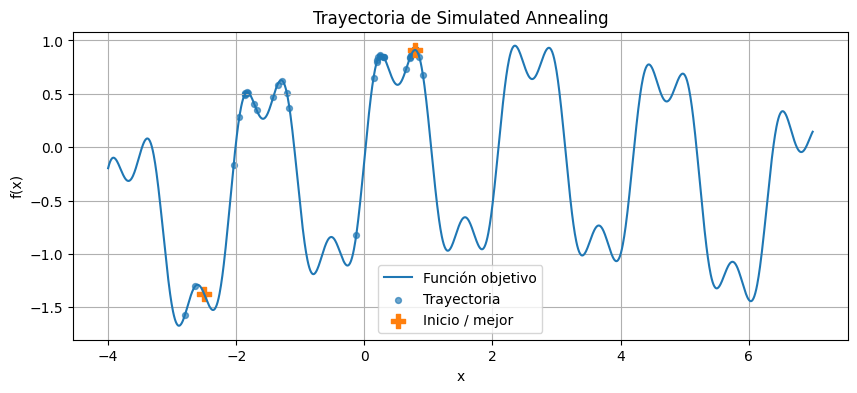

In [ ]:
trajectory_x = [r['x'] for r in records]
trajectory_y = [r['value'] for r in records]

plt.figure(figsize=(10, 4))
plt.plot(xs, ys, label='Función objetivo')
plt.scatter(trajectory_x[::12], trajectory_y[::12], s=18, alpha=0.65, label='Trayectoria')
plt.scatter([x0, sa_x], [objective(x0), sa_value], s=100, marker='P', label='Inicio / mejor')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Trayectoria de Simulated Annealing')
plt.legend()
plt.grid(True)
plt.show()

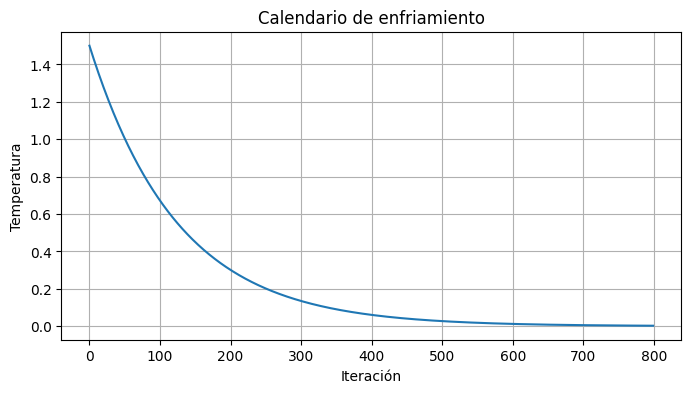

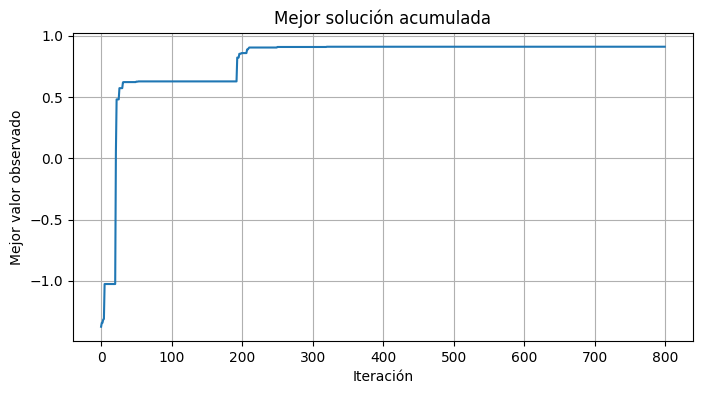

In [ ]:
iterations = [r['iteration'] for r in records]
temperatures = [r['temperature'] for r in records]
best_values = [r['best_value'] for r in records]

plt.figure(figsize=(8, 4))
plt.plot(iterations, temperatures)
plt.xlabel('Iteración')
plt.ylabel('Temperatura')
plt.title('Calendario de enfriamiento')
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(iterations, best_values)
plt.xlabel('Iteración')
plt.ylabel('Mejor valor observado')
plt.title('Mejor solución acumulada')
plt.grid(True)
plt.show()

## 4. Comparación estadística

Una sola corrida puede ser engañosa. Compararemos ambos algoritmos usando múltiples semillas y el mismo punto inicial.

Hill Climbing — media: -0.380, mejor: 0.628
Simulated Annealing — media: 0.527, mejor: 0.951


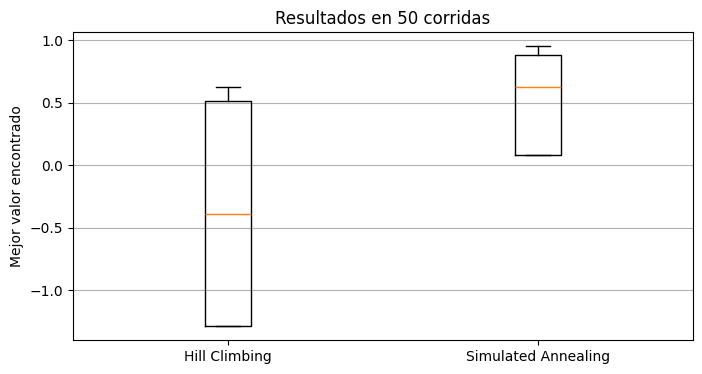

In [ ]:
hill_results = []
sa_results = []

for seed in range(50):
    hx, _ = stochastic_hill_climbing(x0, seed=seed)
    sx, sv, _ = simulated_annealing(x0, seed=seed)
    hill_results.append(float(objective(hx)))
    sa_results.append(sv)

print(f'Hill Climbing — media: {np.mean(hill_results):.3f}, mejor: {np.max(hill_results):.3f}')
print(f'Simulated Annealing — media: {np.mean(sa_results):.3f}, mejor: {np.max(sa_results):.3f}')

plt.figure(figsize=(8, 4))
plt.boxplot([hill_results, sa_results], tick_labels=['Hill Climbing', 'Simulated Annealing'])
plt.ylabel('Mejor valor encontrado')
plt.title('Resultados en 50 corridas')
plt.grid(True, axis='y')
plt.show()

## Actividades

### Actividad 1 — Temperatura inicial

Evalúa $T_0\in\{0.01,0.1,0.5,1,3,10\}$. Para cada valor realiza 30 corridas y registra:

- valor medio de la mejor solución;
- desviación estándar;
- porcentaje de corridas que alcanzan un valor cercano al mejor global aproximado.

In [ ]:
# TODO: completa el experimento.
temperatures_to_test = [0.01, 0.1, 0.5, 1, 3, 10]
experiment = []

for temperature in temperatures_to_test:
    values = []
    for seed in range(30):
        # _, value, _ = simulated_annealing(...)
        # values.append(value)
        pass
    # experiment.append(...)

experiment

### Actividad 2 — Enfriamiento

Compara diferentes valores de $\alpha$ en

$$
T_{t+1}=\alpha T_t
$$

Explica por qué un enfriamiento demasiado rápido puede convertir el algoritmo en Hill Climbing.

### Actividad 3 — Problema discreto

Adapta Simulated Annealing al problema de hospitales del notebook anterior. Recuerda que, al minimizar, puedes definir

$$
\Delta = C(	actual)-C(candidato)
$$

para conservar la misma lógica de aceptación usada en este notebook.

## Preguntas de cierre

1. ¿Por qué Simulated Annealing conserva la mejor solución observada, además de la solución actual?
2. ¿Qué ocurre si la temperatura nunca disminuye?
3. ¿Qué ocurre si la temperatura inicial es prácticamente cero?
4. ¿Simulated Annealing garantiza el óptimo global con un número finito de iteraciones?